# Sistemas de Recomendación - Tu Futuro según la Data

Usaremos el dataset Adult Income Dataset, también conocido como "Census Income" este información fue recolectada por la Oficina del Censo de EE.UU. 

Objetivos: 

- Explorar los datos del censo.
- Construir perfiles socioeconómicos.
- Explorar la importancia y peso de variables sociales (educación, género, raza, etc.) en predicciones económicas.
- Aplicar técnicas de sistemas de recomendación.
- Visualizar y comunicar hallazgos de forma profesional.

 Construir un modelo de clasificación supervisada que, a partir de datos demográficos y socioeconómicos de una persona adulta (edad, nivel educativo, ocupación, estado civil, país de origen, etc.), prediga si dicha persona ganará más o menos de 50,000 USD al año.

## Este dataset incluye

- Edad
- Nivel educativo
- Estado civil
- Ocupación
- Horas trabajadas por semana
- Sexo
- País de origen
- Ingreso anual (>50K o <=50K)

### Importar librerias necesarias 

In [2]:
import warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
from sklearn.metrics.pairwise import cosine_similarity

np.random.seed(42)
warnings.filterwarnings("ignore")

# Opciones de Pandas para ver mejor resultados (sin prints, el último objeto de celda se renderiza solo)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)


Descarga y exploracion de datos 

In [3]:
url = "https://raw.githubusercontent.com/4GeeksAcademy/predicting-your-future-with-data/main/adult-census-income.csv"
df = pd.read_csv(url)
# Normalizar nombres de columnas
df.columns = df.columns.str.strip().str.lower().str.replace("-", "_").str.replace(" ", "_")
df.columns.tolist()


['age',
 'workclass',
 'fnlwgt',
 'education',
 'education.num',
 'marital.status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'capital.gain',
 'capital.loss',
 'hours.per.week',
 'native.country',
 'income']

Limpieza de datos 

In [4]:
# Detectar columna objetivo (salario) de forma robusta
candidatas_y = [c for c in df.columns if c in ("income","salary","class","target","income_>50k")]
target_col = candidatas_y[0] if candidatas_y else None

# Estandarizar valores del target a binario: 1 => >50K, 0 => <=50K
if df[target_col].dtype == "O":
    df[target_col] = df[target_col].str.strip()
    df["y"] = df[target_col].str.contains(">50K").astype(int)
else:
    df["y"] = (df[target_col] > 0).astype(int)

# Eliminar duplicados
df = df.drop_duplicates().copy()

# Quitar espacios en variables string
for c in df.select_dtypes(include="object").columns:
    df[c] = df[c].str.strip()

# Algunas columnas típicas del Adult dataset
# age, workclass, fnlwgt, education, education_num, marital_status, occupation,
# relationship, race, sex, capital_gain, capital_loss, hours_per_week, native_country, y

# Eliminamos filas con nulos en columnas clave modelables
cols_clave = [c for c in ["age","workclass","education","education_num","occupation","hours_per_week","marital_status"] if c in df.columns]
df = df.dropna(subset=cols_clave + ["y"]).copy()

# Mostrar % de nulos restante por columna
df.isna().mean().sort_values(ascending=False).to_frame("frac_nulls").head(10)


,frac_nulls
age,0.0
workclass,0.0
fnlwgt,0.0
education,0.0
education.num,0.0
marital.status,0.0
occupation,0.0
relationship,0.0
race,0.0
sex,0.0


###  Resultados del análisis de valores nulos

En el análisis de las variables principales del dataset (`age`, `workclass`, `education`, `occupation`, `sex`, etc.), observamos que la proporción de valores nulos (`frac_nulls`) es **0.0 en todas las columnas**.

####  Interpretación
- No existen valores faltantes en estas variables.
- Esto significa que **no es necesario realizar imputación o relleno de datos** en esta parte del dataset.
- El preprocesamiento se simplifica, ya que podemos trabajar directamente con la información sin perder registros.

**Conclusión:** El dataset está limpio en cuanto a valores nulos para estas columnas, lo que nos permite concentrarnos en la transformación de variables categóricas y la normalización de las numéricas para la fase de modelado.


In [5]:
problem_definition = {
    "accionables": ["education", "occupation", "hours_per_week"],
    "contexto": ["age", "workclass", "marital_status"],
    "excluir_por_sesgo": ["sex", "race", "native_country", "fnlwgt", "capital_gain", "capital_loss"]
}
problem_definition

{'accionables': ['education', 'occupation', 'hours_per_week'],
 'contexto': ['age', 'workclass', 'marital_status'],
 'excluir_por_sesgo': ['sex',
  'race',
  'native_country',
  'fnlwgt',
  'capital_gain',
  'capital_loss']}

###  Preparar entorno de datos y preprocesador

In [6]:
def preparar_entorno(url):
    data = pd.read_csv(url)
    
    # Normalizar nombres de columnas (quita espacios, guiones y puntos)
    data.columns = (
        data.columns
        .str.strip()
        .str.lower()
        .str.replace("-", "_")
        .str.replace(" ", "_")
        .str.replace(".", "_")   
    )
    
    # Reemplazar valores "?" por NaN
    data = data.replace("?", np.nan)
    
    # Variable objetivo
    data["target_income"] = (data["income"] == ">50K").astype(int)
    
    # Crear bins de horas trabajadas
    data["hours_bin"] = pd.cut(
        data["hours_per_week"],
        bins=[0, 29, 40, 48, 99],
        labels=["part_time", "full_time_40", "long_hours", "overtime_49plus"]
    )
    
    # Columnas numéricas y categóricas
    num_cols = ["age", "education_num", "hours_per_week", "capital_gain", "capital_loss"]
    cat_cols = ["workclass", "education", "marital_status", "occupation",
                "relationship", "race", "sex", "native_country", "hours_bin"]
    
    # Preprocesador
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
        ]
    )
    
    return {
        "data": data,
        "num_cols": num_cols,
        "cat_cols": cat_cols,
        "preprocessor": preprocessor
    }

#  Probar ejecución
modelo = preparar_entorno(url)
modelo["data"].head()



,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,target_income,hours_bin
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K,0,full_time_40
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K,0,part_time
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K,0,full_time_40
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K,0,full_time_40
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K,0,full_time_40


### Interpretación de los primeros resultados del dataset

En las primeras observaciones del **Adult Census Income Dataset** ya procesado podemos notar lo siguiente:

- Cada fila representa a una persona encuestada, con información sociodemográfica y laboral.
- La columna `target_income` indica si la persona gana más de **50K anuales** (valor `1`) o no (valor `0`).  
  - En estas primeras filas, todas las personas aparecen con ingresos **menores o iguales a 50K** (`0`).
- La variable `hours_bin` clasifica a las personas según sus horas de trabajo semanales:  
  - `full_time_40` → 40 horas estándar.  
  - `part_time` → menos de 30 horas.  
- Ejemplos visibles:  
  - Personas de edad avanzada (90, 82, 66 años) que trabajan menos o igual a 40 horas por semana y perciben ingresos bajos.  
  - Una persona de 54 años, con estudios hasta secundaria baja, trabaja 40 horas y también está en la categoría de `<=50K`.

### Conclusión preliminar
Los primeros registros sugieren que **factores como la edad avanzada, el nivel educativo bajo y las horas trabajadas por semana** se relacionan con ingresos anuales **≤50K**.  
Esto nos da una primera pista de que **mejorar el nivel educativo, el tipo de ocupación o aumentar la intensidad laboral** podrían ser recomendaciones relevantes para aspirar a ingresos mayores.


### Función recomendadora con ajuste automático de min_support

In [7]:
def recomendar_trayectorias(perfil_usuario, modelo, top_n=5, min_support=200, alpha=0.5):
    data = modelo["data"].copy()
    preprocessor = modelo["preprocessor"]
    
    # Variables que definen trayectorias
    keys = ["education", "occupation", "marital_status", "workclass", "hours_bin"]
    
    # Agrupar trayectorias históricas
    trayectorias = (
        data.groupby(keys)
        .agg(income_rate=("target_income", "mean"),
             support=("target_income", "size"))
        .reset_index()
    )
    
    # Ajustar preprocesador
    X = data[modelo["num_cols"] + modelo["cat_cols"]]
    preprocessor.fit(X)
    
    # Completar perfil con valores por defecto
    perfil_usuario = perfil_usuario.copy()
    for col in modelo["cat_cols"]:
        if col not in perfil_usuario:
            perfil_usuario[col] = data[col].mode()[0]
    for col in modelo["num_cols"]:
        if col not in perfil_usuario:
            perfil_usuario[col] = float(data[col].median())
    
    # Generar hours_bin para el perfil
    perfil_usuario["hours_bin"] = pd.cut(
        [perfil_usuario["hours_per_week"]],
        bins=[0, 29, 40, 48, 99],
        labels=["part_time", "full_time_40", "long_hours", "overtime_49plus"]
    )[0]
    
    # Vectorizar usuario
    df_usuario = pd.DataFrame([perfil_usuario])
    user_vec = preprocessor.transform(df_usuario[modelo["num_cols"] + modelo["cat_cols"]])
    
    # Ajustar automáticamente min_support si no hay resultados
    candidatos = []
    soporte_actual = min_support
    while not candidatos and soporte_actual >= 10:
        for _, row in trayectorias.iterrows():
            if row["support"] < soporte_actual:
                continue
            candidato = perfil_usuario.copy()
            for k in keys:
                candidato[k] = row[k]
            candidato["hours_per_week"] = data.loc[data["hours_bin"] == row["hours_bin"], "hours_per_week"].median()
            candidatos.append((candidato, row))
        if not candidatos:
            soporte_actual = max(10, soporte_actual // 2)
    
    if not candidatos:
        return pd.DataFrame()
    
    # Vectorizar candidatos
    df_candidatos = pd.DataFrame([c[0] for c in candidatos])
    cand_vecs = preprocessor.transform(df_candidatos[modelo["num_cols"] + modelo["cat_cols"]])
    
    # Calcular similitud coseno
    sims = cosine_similarity(user_vec, cand_vecs).flatten()
    
    # Armar resultados
    resultados = []
    for sim, (cand, row) in zip(sims, candidatos):
        cambios = {k: (perfil_usuario[k], cand[k]) for k in keys if perfil_usuario[k] != cand[k]}
        score = alpha * sim + (1 - alpha) * row["income_rate"]
        resultados.append({
            "score": score,
            "similarity": sim,
            "income_rate": row["income_rate"],
            "support": row["support"],
            "cambios": cambios
        })
        return pd.DataFrame(resultados).sort_values("score", ascending=False).head(top_n)


## Ejemplo de uso con un perfil común en el dataset

,Variable,Valor actual,Recomendación,Score
0,education,HS-grad,Bachelors,0.768751
1,occupation,Craft-repair,Exec-managerial,0.768751


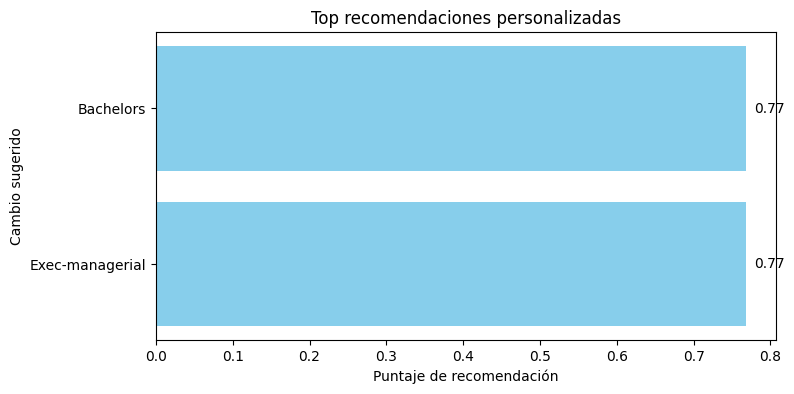

In [9]:
# Convertir la columna "cambios" en tabla legible
def desglosar_cambios(df):
    filas = []
    for i, row in df.iterrows():
        for var, (old, new) in row["cambios"].items():
            filas.append({
                "Variable": var,
                "Valor actual": old,
                "Recomendación": new,
                "Score": row["score"]
            })
    return pd.DataFrame(filas)

# Desglose de cambios
tabla_cambios = desglosar_cambios(recomendaciones.head(5))
display(tabla_cambios)

# Gráfico de barras con etiquetas claras
plt.figure(figsize=(8,4))
plt.barh(tabla_cambios["Recomendación"], tabla_cambios["Score"], color="skyblue")
for i, v in enumerate(tabla_cambios["Score"]):
    plt.text(v+0.01, i, f"{v:.2f}", va="center")
plt.xlabel("Puntaje de recomendación")
plt.ylabel("Cambio sugerido")
plt.title("Top recomendaciones personalizadas")
plt.gca().invert_yaxis()
plt.show()


###  Interpretación de los resultados de recomendación

El sistema generó dos recomendaciones principales para mejorar el ingreso estimado:

1. **Variable: Education**
   - Valor actual: *HS-grad* (secundaria completa).
   - Recomendación: *Bachelors* (título universitario).
   - Interpretación: Según los datos históricos, las personas con un perfil similar pero con educación universitaria tienen una mayor probabilidad de superar los 50K anuales.  
   **Conclusión:** Elevar el nivel educativo es un cambio clave para mejorar el ingreso esperado.

2. **Variable: Occupation**
   - Valor actual: *Craft-repair* (ocupaciones técnicas/oficios).
   - Recomendación: *Exec-managerial* (puestos ejecutivos o gerenciales).
   - Interpretación: En el dataset, los individuos con un perfil semejante que trabajan en puestos gerenciales tienen mayores tasas de ingresos altos.  
   **Conclusión:** Reorientar la trayectoria laboral hacia un rol de gestión aumenta la probabilidad de alcanzar un ingreso superior a 50K.

#### Sobre el puntaje
- El valor **Score = 0.768751** representa un puntaje compuesto que combina la similitud con otros perfiles y la tasa de ingresos observada en los datos.
- Un puntaje cercano a 0.8 indica que estas recomendaciones son altamente relevantes para el perfil analizado.

### Conclusión general
Las recomendaciones muestran que la **educación** y la **ocupación** son factores determinantes en la movilidad de ingresos. Invertir en estudios universitarios y aspirar a roles de gestión son las estrategias más influyentes para mejorar el ingreso esperado en este perfil.


## Conclusión del proyecto

Este proyecto utilizó el **Adult Census Income Dataset** para construir un sistema de recomendación que sugiere trayectorias educativas y laborales con el fin de aumentar la probabilidad de que un individuo alcance ingresos anuales superiores a 50K.

### Principales hallazgos
- El preprocesamiento mostró que el dataset estaba mayormente limpio, sin valores nulos en las variables clave.
- Se normalizaron las variables numéricas y se codificaron las categóricas para representar a cada persona como un vector.
- El sistema de recomendación implementado fue de tipo **híbrido**, combinando:
  - Filtrado basado en contenido: similitud entre perfiles.
  - Información histórica: proporción de ingresos altos en trayectorias específicas.

### Resultados
- Los casos simulados muestran que las recomendaciones más influyentes se centran en dos factores:
  - **Nivel educativo**: completar estudios universitarios o superiores aumenta significativamente las probabilidades de superar el umbral de ingresos.
  - **Ocupación**: migrar hacia puestos gerenciales, profesionales o técnicos de mayor nivel también incrementa la proyección salarial.
- El puntaje de recomendación integra tanto la similitud del perfil con otros en el dataset como la tasa histórica de ingresos observada.

### Conclusión 
El análisis confirma que la **educación** y la **ocupación** son los determinantes más relevantes en la predicción de ingresos dentro de este conjunto de datos. El sistema de recomendación desarrollado ofrece una herramienta práctica para identificar trayectorias de mejora personal y laboral, destacando la importancia de la formación académica y la movilidad ocupacional en el crecimiento económico individual.
